# Pattern 별 시각화

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
df = pd.read_csv('collection_yearly_out1_weighted_rating_2_3.csv')

In [73]:
df

,collection,2022_rating,2022_sales,2022_weight,2022_contribution,2022_wei_acc,2022_wei_avg,2023_rating,2023_sales,2023_weight,...,2024_contribution,2024_wei_avg,2025_rating,2025_sales,2025_weight,2025_contribution,2025_acc_contribution,rating,contribution,Pattern
0,12in MyGel w WonderBox,0.0,0.00,0.0,0.00%,0.0,#DIV/0!,0.0,0.0,0.0,...,5.10%,3.824929441,3.130328,5589616.65,17497331.19,7.07%,7.07%,down,up,P3
1,12in GTMF w WonderBox,0.0,0.00,0.0,0.00%,0.0,#DIV/0!,0.0,0.0,0.0,...,7.60%,3.404387568,2.826828,6066751.89,17149661.11,6.93%,14.01%,down,down,P4
2,10in MyGel w WonderBox,0.0,0.00,0.0,0.00%,0.0,#DIV/0!,0.0,0.0,0.0,...,2.40%,3.501787778,3.076587,5063826.21,15579303.41,6.30%,20.30%,down,up,P3
3,10in GTMF w WonderBox,0.0,0.00,0.0,0.00%,0.0,#DIV/0!,0.0,0.0,0.0,...,4.50%,3.692386098,3.152511,4677993.61,14747424.83,5.96%,26.27%,down,up,P3
4,6in GTMF w WonderBox,0.0,0.00,0.0,0.00%,0.0,#DIV/0!,0.0,0.0,0.0,...,3.80%,3.374506342,3.595635,3433009.19,12343847.73,4.99%,31.26%,up,up,P1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
664,Wesley Side Table,0.0,798.18,0.0,0.00%,0.0,0,0.0,0.0,0.0,...,0.00%,0,0.000000,0.00,0.00,0.00%,100.00%,NaN,NaN,NaN
665,William Trestle Table,0.0,533.33,0.0,0.00%,0.0,0,0.0,0.0,0.0,...,0.00%,0,0.000000,0.00,0.00,0.00%,100.00%,NaN,NaN,NaN
666,WonderBox Kellen,0.0,0.00,0.0,0.00%,0.0,#DIV/0!,0.0,0.0,0.0,...,0.00%,#DIV/0!,0.000000,6012.00,0.00,0.00%,100.00%,NaN,NaN,NaN
667,Wood Squre Dining Table,0.0,0.00,0.0,0.00%,0.0,#DIV/0!,0.0,0.0,0.0,...,0.00%,#DIV/0!,0.000000,0.00,0.00,0.00%,100.00%,NaN,NaN,NaN


In [75]:
#rating 컬럼만 추출해서 long format으로 변환
rating_cols = [col for col in df.columns if "rating" in col and col[:4].isdigit()]

In [77]:
df_rating = df.melt(
    id_vars=['Pattern'], value_vars=rating_cols, var_name='year', value_name='Rating'
)

In [79]:
df_rating['year'] = df_rating['year'].str[:4].astype(int)

In [81]:
df_rating

,Pattern,year,Rating
0,P3,2022,0.0
1,P4,2022,0.0
2,P3,2022,0.0
3,P3,2022,0.0
4,P1,2022,0.0
...,...,...,...
2671,NaN,2025,0.0
2672,NaN,2025,0.0
2673,NaN,2025,0.0
2674,NaN,2025,0.0


In [85]:
df_filtered = df_rating[df_rating['Rating']>0]

In [91]:
pattern_year_avg = df_filtered.groupby(['Pattern','year'])['Rating'].mean().reset_index()

In [93]:
pattern_year_avg

,Pattern,year,Rating
0,P1,2022,4.139303
1,P1,2023,4.057106
2,P1,2024,3.408770
3,P1,2025,4.166151
4,P2,2022,3.990758
5,P2,2023,3.819261
6,P2,2024,3.751416
7,P2,2025,4.612200
8,P3,2022,4.372449
9,P3,2023,4.391567


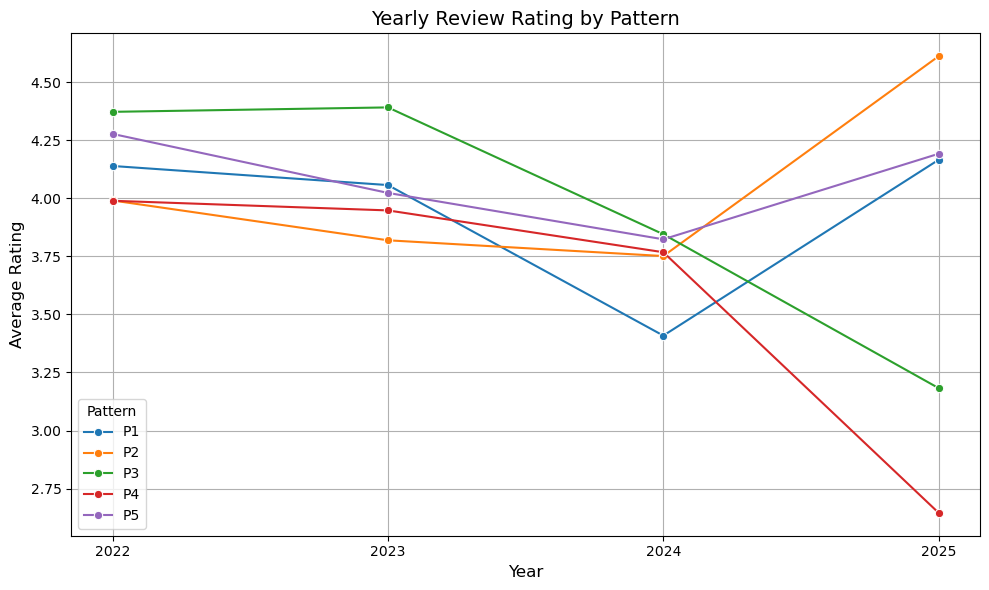

In [107]:
plt.figure(figsize=(10,6))
sns.lineplot(data=pattern_year_avg, x='year', y='Rating', hue='Pattern', marker='o')

# X축 연도 설정
plt.xticks(sorted(pattern_year_avg["year"].unique()))
plt.title("Yearly Review Rating by Pattern", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)
plt.grid(True)
plt.legend(title="Pattern")
plt.tight_layout()
plt.show()

## 가중 평균 시각화 추가

In [6]:
# 데이터 로드
df = pd.read_csv("collection_yearly_out1_weighted_rating_2_3.csv")

In [ ]:
df

In [10]:
# 컬럼 추출
rating_cols = [col for col in df.columns if "rating" in col and col[:4].isdigit()]
sales_cols = [col for col in df.columns if "sales" in col and col[:4].isdigit()]
weight_cols = [col for col in df.columns if "weight" in col and col[:4].isdigit()]


In [12]:
rating_cols

['2022_rating', '2023_rating', '2024_rating', '2025_rating']

In [14]:
# long format 변환 (melt)
df_rating = df.melt(id_vars=["Pattern"], value_vars=rating_cols, var_name="year", value_name="rating_value")
df_sales = df.melt(id_vars=["Pattern"], value_vars=sales_cols, var_name="year", value_name="sales_value")
df_weight = df.melt(id_vars=["Pattern"], value_vars=weight_cols, var_name="year", value_name="weight_value")


In [16]:
# 연도 추출 (문자열로 변환 후 자르기)
df_rating["year"] = df_rating["year"].astype(str).str[:4].astype(int)
df_sales["year"] = df_sales["year"].astype(str).str[:4].astype(int)
df_weight["year"] = df_weight["year"].astype(str).str[:4].astype(int)


In [24]:
# 세 DataFrame을 Pattern + year 기준으로 정렬
df_rating = df_rating.sort_values(["Pattern", "year"]).reset_index(drop=True)
df_sales = df_sales.sort_values(["Pattern", "year"]).reset_index(drop=True)
df_weight = df_weight.sort_values(["Pattern", "year"]).reset_index(drop=True)

In [26]:
# concat으로 병합 (index 기준으로 수평 결합)
df_combined = pd.concat([
    df_rating, 
    df_sales["sales_value"], 
    df_weight["weight_value"]
], axis=1)


In [28]:
# 패턴별, 연도별로 그룹화하여 집계
pattern_yearly_summary = df_combined.groupby(["Pattern", "year"]).agg(
    avg_rating=("rating_value", "mean"),
    sum_sales=("sales_value", "sum"),
    sum_weight=("weight_value", "sum")
).reset_index()


In [32]:
pattern_yearly_summary['weighted_rating'] = pattern_yearly_summary['sum_weight']/pattern_yearly_summary['sum_sales']

In [34]:
# 결과 출력
print(pattern_yearly_summary)

   Pattern  year  avg_rating     sum_sales    sum_weight  weighted_rating
0       P1  2022    0.591329  6.532217e+06  2.703463e+07         4.138661
1       P1  2023    0.724483  5.942208e+06  2.463141e+07         4.145161
2       P1  2024    3.043545  3.399631e+07  1.164326e+08         3.424861
3       P1  2025    4.166151  1.490734e+07  5.898842e+07         3.957006
4       P2  2022    3.140268  1.163012e+08  4.684921e+08         4.028265
5       P2  2023    3.130542  8.196309e+07  3.197079e+08         3.900633
6       P2  2024    3.751416  3.495394e+07  1.336736e+08         3.824279
7       P2  2025    4.612200  2.714040e+06  1.224495e+07         4.511706
8       P3  2022    0.230129  9.011038e+05  3.940031e+06         4.372449
9       P3  2023    0.231135  1.995494e+06  8.761930e+06         4.390858
10      P3  2024    3.845281  6.943713e+07  2.628303e+08         3.785154
11      P3  2025    3.182534  3.127855e+07  9.984977e+07         3.192277
12      P4  2022    3.361549  4.218860

In [58]:
### 1. P1, P2만 시각화
df_filtered = pattern_yearly_summary[pattern_yearly_summary["Pattern"].isin(["P3", "P4"])]


In [60]:
df_filtered

,Pattern,year,avg_rating,sum_sales,sum_weight,weighted_rating
8,P3,2022,0.230129,9.011038e+05,3.940031e+06,4.372449
9,P3,2023,0.231135,1.995494e+06,8.761930e+06,4.390858
10,P3,2024,3.845281,6.943713e+07,2.628303e+08,3.785154
11,P3,2025,3.182534,3.127855e+07,9.984977e+07,3.192277
12,P4,2022,3.361549,4.218860e+08,1.600137e+09,3.792817
13,P4,2023,3.399652,3.461634e+08,1.281777e+09,3.702808
14,P4,2024,3.767867,1.606952e+08,5.788322e+08,3.602051
15,P4,2025,2.645399,1.560615e+07,4.692781e+07,3.007008


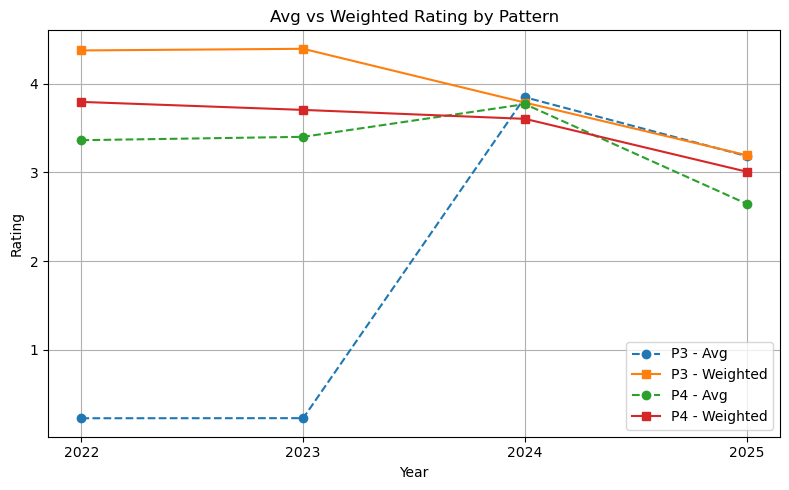

In [62]:
# 선 그래프
plt.figure(figsize=(8, 5))
for pattern in df_filtered["Pattern"].unique():
    subset = df_filtered[df_filtered["Pattern"] == pattern]
    plt.plot(subset["year"], subset["avg_rating"], marker='o', linestyle='--', label=f"{pattern} - Avg")
    plt.plot(subset["year"], subset["weighted_rating"], marker='s', linestyle='-', label=f"{pattern} - Weighted")

plt.title("Avg vs Weighted Rating by Pattern")
plt.xlabel("Year")
plt.ylabel("Rating")
plt.xticks(df_filtered["year"].unique())  # 4자리 연도 고정
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()